# ResNet50 – Multi-Label Apparel Classification

## Task 3.1 – Multi-Label Classification

This notebook implements:

- ResNet50 (Transfer Learning)
- ResNet50 (Training from Scratch)
- ResNet50 ( Fine Tuning)

Dataset:
- DeepFashion2 (Top-5 categories pruned)

Loss:
- BCEWithLogitsLoss (multi-label)

Evaluation:
- Per-class Precision
- Per-class Recall
- Per-class F1
- Macro F1
- Micro F1
- ROC-AUC

In [1]:
# ===============================
#  Imports
# ===============================

import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.amp import GradScaler, autocast  # Mixed Precision

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ===============================
#  Reproducibility
# ===============================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# ===============================
#  Speed Optimization
# ===============================

# Allows cuDNN to find the best algorithm for your hardware
torch.backends.cudnn.benchmark = True

# ===============================
#  Device Configuration
# ===============================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Step 1: Load Preprocessed Data

We load:
- train_samples
- val_samples
- pos_weights
- category_map

These were generated in the preprocessing notebook.

In [2]:
# ===============================
#  Load Preprocessed Dataset
# ===============================

PREPROC_PATH = "/kaggle/input/datasets/harshitabansal307/deepfashion-classification-preprocessed"

train_samples = torch.load(os.path.join(PREPROC_PATH, "train_samples.pt"), map_location="cpu")
val_samples = torch.load(os.path.join(PREPROC_PATH, "val_samples.pt"), map_location="cpu")
pos_weights = torch.load(os.path.join(PREPROC_PATH, "pos_weights.pt"), map_location="cpu")
category_map = torch.load(os.path.join(PREPROC_PATH, "category_map.pt"), map_location="cpu")

# Move weights to GPU for BCEWithLogitsLoss
pos_weights = pos_weights.to(device)

print("Train samples:", len(train_samples))
print("Validation samples:", len(val_samples))
print("Category mapping:", category_map)
print("Positive weights device:", pos_weights.device)

Train samples: 144174
Validation samples: 23741
Category mapping: {1: 0, 8: 1, 7: 2, 2: 3, 9: 4}
Positive weights device: cuda:0


## Step 2: Define Dataset Paths

* Defines base path for the **pruned DeepFashion dataset**.
* Specifies directories for **training and validation images**.
* Uses the previously defined **preprocessed dataset path** for loading classification samples.


In [3]:
# ===============================
#  Dataset Paths
# ===============================

# Original pruned DeepFashion dataset
DATASET_PATH = "/kaggle/input/datasets/harshitabansal307/deepfashion-pruned-dataset"

TRAIN_IMG_DIR = os.path.join(DATASET_PATH, "train", "images")
VAL_IMG_DIR   = os.path.join(DATASET_PATH, "validation", "images")

print("Train image directory:", TRAIN_IMG_DIR)
print("Validation image directory:", VAL_IMG_DIR)
print("Preprocessed dataset:", PREPROC_PATH)

Train image directory: /kaggle/input/datasets/harshitabansal307/deepfashion-pruned-dataset/train/images
Validation image directory: /kaggle/input/datasets/harshitabansal307/deepfashion-pruned-dataset/validation/images
Preprocessed dataset: /kaggle/input/datasets/harshitabansal307/deepfashion-classification-preprocessed


## Step 3: Define Image Transformations

For Training:
- Resize to 224×224
- Random horizontal flip
- Small rotation
- Color jitter
- Normalize (ImageNet mean/std)

For Validation:
- Resize
- Normalize
(No augmentation)

In [4]:
# ===============================
#  Image Transformations
# ===============================

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

print("Transforms defined successfully.")

Transforms defined successfully.


## Step 4: Create Custom Dataset Class

This Dataset:

- Loads image from path
- Applies transforms
- Returns:
    - Image tensor
    - Multi-label tensor (size = 5)

Images are loaded dynamically (not stored in memory).

In [5]:
# ===============================
#  Custom Dataset Class
# ===============================

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True


class DeepFashionMultiLabelDataset(Dataset):
    
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform
        
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        
        # Load image
        image = Image.open(img_path).convert("RGB")
        
        # Apply transforms
        if self.transform:
            image = self.transform(image)
        
        # Convert label to tensor
        label = torch.tensor(label, dtype=torch.float32)
        
        return image, label

## Step 5: Create Dataset Objects

We create:

- Training dataset (with augmentation)
- Validation dataset (no augmentation)

These will be used by DataLoader to generate batches.

In [6]:
# ===============================
#  Custom Dataset Class
# ===============================

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True


class DeepFashionMultiLabelDataset(Dataset):
    
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform
        
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        try:
            image = Image.open(img_path).convert("RGB")
        except Exception:
            # fallback in case image fails
            image = Image.new("RGB", (224, 224))

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.float32)

        return image, label

In [7]:
# ===============================
# Create Dataset Objects
# ===============================

train_dataset = DeepFashionMultiLabelDataset(
    train_samples,
    transform=train_transforms
)

val_dataset = DeepFashionMultiLabelDataset(
    val_samples,
    transform=val_transforms
)

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))

Train dataset size: 144174
Validation dataset size: 23741


## Step 6: Create DataLoaders

DataLoader:
- Loads data in batches
- Shuffles training data
- Uses GPU efficiently

In [8]:
# ===============================
#  Create DataLoaders
# ===============================

from torch.utils.data import WeightedRandomSampler

BATCH_SIZE = 32  # Increase to 64 if GPU memory allows

# -------------------------------
# Compute sample weights
# -------------------------------
sample_weights = []
for _, label in train_samples:
    weight = sum(pos_weights[i].item() * label[i] for i in range(len(label))) + 1e-6
    sample_weights.append(weight)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# -------------------------------
# Train DataLoader
# -------------------------------
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=4,
    pin_memory=True,
   # persistent_workers=True
)

# -------------------------------
# Validation DataLoader
# -------------------------------
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    #persistent_workers=True
)

print(f"DataLoaders ready with {len(train_loader)} batches per epoch.")

DataLoaders ready with 4506 batches per epoch.


In [9]:
try:
    images, labels = next(iter(train_loader))
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

    images = images.to(device)
    labels = labels.to(device)

    print("Device of images:", images.device)
    print("Device of labels:", labels.device)

except Exception as e:
    print("DataLoader check failed:", e)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32, 5])
Device of images: cuda:0
Device of labels: cuda:0


## Step 7: Build ResNet50 - Fine Tuning

* Loads **ResNet50 pretrained on ImageNet**.
* Replaces the final fully connected layer to match the **number of clothing classes**.
* Enables training for **all layers** to perform full fine-tuning.
* Moves the model to the **GPU device** for training.


In [10]:
# ===============================
#  Build ResNet50 (Fine-Tuning)
# ===============================

NUM_CLASSES = len(category_map)

# Load pretrained ResNet50
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# Unfreeze ALL layers for full fine-tuning
for param in model.parameters():
    param.requires_grad = True

# Replace final classification layer
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, NUM_CLASSES)

# Move model to GPU
model = model.to(device)

print("ResNet50 (Fine-Tuning) ready.")

ResNet50 (Fine-Tuning) ready.


## Step 8: Define Loss function and Optimizer

* Uses **BCEWithLogitsLoss** for multi-label classification.
* Applies **positive class weights** to address class imbalance.
* Optimizes only **trainable parameters** of the model.
* Uses the **Adam optimizer** with a small learning rate for stable fine-tuning.


In [11]:
# ===============================
#  Loss and Optimizer
# ===============================

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)

print("Loss and optimizer ready.")

Loss and optimizer ready.


## Step 9: Training and Validation Loop

* Trains the model for a fixed number of **epochs**.
* Uses **mixed precision (autocast + GradScaler)** to speed up training.
* Computes **training and validation loss** each epoch.
* Generates predictions using **sigmoid activation with threshold 0.5**.
* Evaluates performance using **Macro F1-score**.
* Saves the **best model weights** based on validation Macro F1.


In [12]:
# ===============================
#  Training Loop
# ===============================

from tqdm import tqdm
import copy
from sklearn.metrics import f1_score

EPOCHS = 8

scaler = GradScaler("cuda")

best_macro_f1 = 0
best_model_weights = None

train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    # ----- Training -----
    model.train()
    running_train_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with autocast("cuda"):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_train_loss += loss.item() * images.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)


    # ----- Validation -----
    model.eval()
    running_val_loss = 0.0

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            all_labels.append(labels.cpu().numpy())
            all_preds.append(preds.cpu().numpy())

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    all_labels = np.vstack(all_labels)
    all_preds = np.vstack(all_preds)

    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss : {epoch_train_loss:.4f}")
    print(f"Val Loss   : {epoch_val_loss:.4f}")
    print(f"Macro F1   : {macro_f1:.4f}")

    if macro_f1 > best_macro_f1:
        best_macro_f1 = macro_f1
        best_model_weights = copy.deepcopy(model.state_dict())

        torch.save(model.state_dict(),
               "/kaggle/working/resnet50_best_finetune.pth")

print("\nTraining complete.")

model.load_state_dict(best_model_weights)
print("Best model loaded (based on Macro F1).")

Epoch 1/8: 100%|██████████| 4506/4506 [13:19<00:00,  5.64it/s]



Epoch [1/8]
Train Loss : 0.5612
Val Loss   : 0.3960
Macro F1   : 0.7928


Epoch 2/8: 100%|██████████| 4506/4506 [12:19<00:00,  6.10it/s]



Epoch [2/8]
Train Loss : 0.3903
Val Loss   : 0.3473
Macro F1   : 0.8173


Epoch 3/8: 100%|██████████| 4506/4506 [12:02<00:00,  6.24it/s]


...


Epoch [6/8]
Train Loss : 0.2504
Val Loss   : 0.3244
Macro F1   : 0.8419


Epoch 7/8: 100%|██████████| 4506/4506 [11:51<00:00,  6.33it/s]



Epoch [7/8]
Train Loss : 0.2290
Val Loss   : 0.3288
Macro F1   : 0.8431


Epoch 8/8: 100%|██████████| 4506/4506 [11:48<00:00,  6.36it/s]



Epoch [8/8]
Train Loss : 0.2106
Val Loss   : 0.3304
Macro F1   : 0.8494

Training complete.
Best model loaded (based on Macro F1).


## Step 10: Evaluation Metrics (Multi-Label)

We compute:

- Per-class Precision
- Per-class Recall
- Per-class F1
- Macro F1
- Micro F1
- ROC-AUC

In [13]:
# ===============================
#  Evaluation Function
# ===============================

def evaluate_model(model, data_loader):

    model.eval()

    all_labels = []
    all_outputs = []

    with torch.no_grad():
        for images, labels in tqdm(data_loader):

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            all_labels.append(labels.cpu())
            all_outputs.append(outputs.cpu())

    all_labels = torch.cat(all_labels).numpy()
    all_outputs = torch.cat(all_outputs)

    # Probabilities
    probs = torch.sigmoid(all_outputs).numpy()

    # Predictions
    preds = (probs > 0.5).astype(int)

    y_true = all_labels
    y_pred = preds
    y_prob = probs

    precision = precision_score(y_true, y_pred, average=None, zero_division=0)
    recall = recall_score(y_true, y_pred, average=None, zero_division=0)
    f1 = f1_score(y_true, y_pred, average=None, zero_division=0)

    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    micro_f1 = f1_score(y_true, y_pred, average="micro", zero_division=0)

    try:
        roc_auc = roc_auc_score(y_true, y_prob, average=None)
        macro_auc = roc_auc_score(y_true, y_prob, average="macro")
    except:
        roc_auc = [0]*len(category_map)
        macro_auc = 0

    print("\n===== Per Class Metrics =====")

    ordered_categories = list(category_map.values())

    for i in range(len(ordered_categories)):
        print(f"\nClass: {ordered_categories[i]}")
        print(f"Precision: {precision[i]:.4f}")
        print(f"Recall   : {recall[i]:.4f}")
        print(f"F1-score : {f1[i]:.4f}")
        print(f"AUC      : {roc_auc[i]:.4f}")

    print("\n===== Overall Metrics =====")
    print(f"Macro F1 : {macro_f1:.4f}")
    print(f"Micro F1 : {micro_f1:.4f}")
    print(f"Macro AUC: {macro_auc:.4f}")

    # ------------------------------
    # ROC Curves
    # ------------------------------
    from sklearn.metrics import roc_curve, auc

    plt.figure(figsize=(8,6))

    for i, class_name in enumerate(ordered_categories):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_prob[:, i])
        roc_auc_val = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"{class_name} (AUC={roc_auc_val:.2f})")

    plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves for Clothing Categories")
    plt.legend()
    plt.show()

    return macro_f1, micro_f1

### Model Evaluation on Validation Set

* Runs the trained model on the **validation dataset**.
* Computes **per-class metrics** including Precision, Recall, F1-score, and AUC.
* Returns **Macro F1 and Micro F1 scores** for overall performance evaluation.


100%|██████████| 742/742 [01:24<00:00,  8.79it/s]



===== Per Class Metrics =====

Class: 0
Precision: 0.9060
Recall   : 0.8854
F1-score : 0.8956
AUC      : 0.9602

Class: 1
Precision: 0.8672
Recall   : 0.9488
F1-score : 0.9062
AUC      : 0.9792

Class: 2
Precision: 0.7191
Recall   : 0.8841
F1-score : 0.7931
AUC      : 0.9706

Class: 3
Precision: 0.7054
Recall   : 0.9055
F1-score : 0.7930
AUC      : 0.9560

Class: 4
Precision: 0.8065
Recall   : 0.9192
F1-score : 0.8592
AUC      : 0.9717

===== Overall Metrics =====
Macro F1 : 0.8494
Micro F1 : 0.8632
Macro AUC: 0.9675


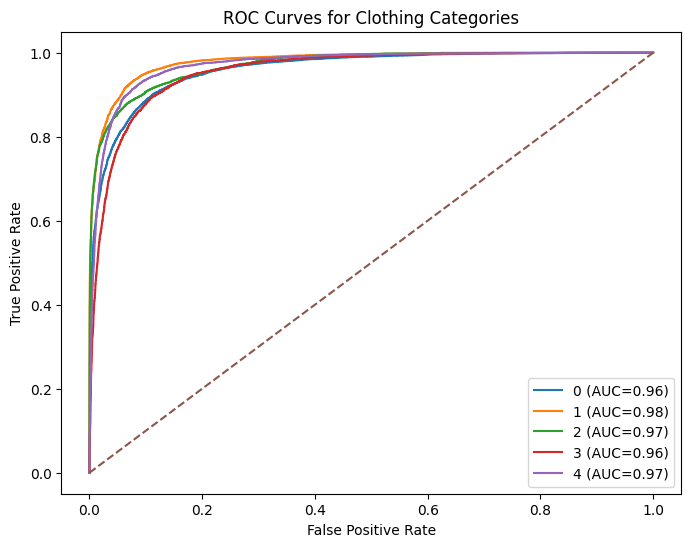


Final Validation Scores
Macro F1: 0.8494314003388155
Micro F1: 0.8631732348618641


In [14]:
macro_f1, micro_f1 = evaluate_model(model, val_loader)

print("\nFinal Validation Scores")
print("Macro F1:", macro_f1)
print("Micro F1:", micro_f1)

In [15]:
# ===============================
# Save trained model
# ===============================

SAVE_PATH = "resnet50_finetune_15epochs.pth"

torch.save(model.state_dict(), SAVE_PATH)

print(f"Model saved successfully at {SAVE_PATH}")

Model saved successfully at resnet50_finetune_15epochs.pth


## Step 11: Build ResNet50 (Training From Scratch)

* Initializes **ResNet50 without pretrained weights**.
* Replaces the final fully connected layer for the **target clothing categories**.
* Applies **Xavier initialization** to the classification layer.
* Moves the model to the **GPU device** for training.


In [16]:
# ===============================
# ResNet50 From Scratch
# ===============================

scratch_model = models.resnet50(weights=None)

# Replace final classification layer
in_features = scratch_model.fc.in_features
scratch_model.fc = nn.Linear(in_features, NUM_CLASSES)

# Initialize final layer
nn.init.xavier_uniform_(scratch_model.fc.weight)
nn.init.zeros_(scratch_model.fc.bias)

# Move model to GPU
scratch_model = scratch_model.to(device)

print("ResNet50 (Scratch) ready.")

ResNet50 (Scratch) ready.


### Loss Function and Optimizer (Scratch Training)

* Uses **BCEWithLogitsLoss** for multi-label classification.
* Applies **positive class weights** to handle class imbalance.
* Optimizes **all parameters of the model** since training starts from scratch.
* Uses a **higher learning rate (1e-4)** for effective learning from random initialization.


In [17]:
# ===============================
# Loss & Optimizer (Scratch)
# ===============================

scratch_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

scratch_optimizer = torch.optim.Adam(
    scratch_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print("Scratch loss and optimizer ready.")

Scratch loss and optimizer ready.


## Step 12: Training Loop (ResNet50 From Scratch)

* Trains the **ResNet50 model initialized from scratch**.
* Computes **training and validation loss** each epoch.
* Uses **sigmoid thresholding (0.5)** for multi-label predictions.
* Evaluates model performance using **Macro F1-score**.
* Saves the **best-performing model weights** based on validation Macro F1.


In [18]:
# ===============================
# Scratch Training Loop
# ===============================

from sklearn.metrics import f1_score
import copy

EPOCHS = 8

best_macro_f1 = 0
best_scratch_weights = None

scratch_train_losses = []
scratch_val_losses = []

for epoch in range(EPOCHS):
    
    # ----- Training -----
    scratch_model.train()
    running_train_loss = 0.0
    
    for images, labels in tqdm(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        
        scratch_optimizer.zero_grad()
        
        outputs = scratch_model(images)
        loss = scratch_criterion(outputs, labels)
        
        loss.backward()
        scratch_optimizer.step()
        
        running_train_loss += loss.item() * images.size(0)
    
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    scratch_train_losses.append(epoch_train_loss)
    
    
    # ----- Validation -----
    scratch_model.eval()
    running_val_loss = 0.0
    
    all_labels = []
    all_preds = []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = scratch_model(images)
            loss = scratch_criterion(outputs, labels)
            
            running_val_loss += loss.item() * images.size(0)
            
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()
            
            all_labels.append(labels.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
    
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    scratch_val_losses.append(epoch_val_loss)
    
    all_labels = np.vstack(all_labels)
    all_preds = np.vstack(all_preds)
    
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    
    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss : {epoch_train_loss:.4f}")
    print(f"Val Loss   : {epoch_val_loss:.4f}")
    print(f"Macro F1   : {macro_f1:.4f}")
    
    
    # Save best model based on Macro F1
    if macro_f1 > best_macro_f1:
        best_macro_f1 = macro_f1
        best_scratch_weights = copy.deepcopy(scratch_model.state_dict())

print("\nScratch Training complete.")

# Load best model
scratch_model.load_state_dict(best_scratch_weights)
print("Best scratch model loaded (based on Macro F1).")

100%|██████████| 4506/4506 [27:51<00:00,  2.70it/s]



Epoch [1/8]
Train Loss : 0.9642
Val Loss   : 0.9668
Macro F1   : 0.4757


100%|██████████| 4506/4506 [27:38<00:00,  2.72it/s]



Epoch [2/8]
Train Loss : 0.8379
Val Loss   : 0.7562
Macro F1   : 0.5916


100%|██████████| 4506/4506 [27:46<00:00,  2.70it/s]


...


Epoch [6/8]
Train Loss : 0.5540
Val Loss   : 0.5344
Macro F1   : 0.7128


100%|██████████| 4506/4506 [27:40<00:00,  2.71it/s]



Epoch [7/8]
Train Loss : 0.5247
Val Loss   : 0.5174
Macro F1   : 0.7283


100%|██████████| 4506/4506 [27:36<00:00,  2.72it/s]



Epoch [8/8]
Train Loss : 0.5024
Val Loss   : 0.4971
Macro F1   : 0.7362

Scratch Training complete.
Best scratch model loaded (based on Macro F1).


## Step 13: Evaluate ResNet50 (From Scratch)

We compute:
- Per-class Precision
- Recall
- F1
- Macro F1
- Micro F1
- ROC-AUC


===== ResNet50 Scratch Evaluation =====


100%|██████████| 742/742 [01:30<00:00,  8.23it/s]



===== Per Class Metrics =====

Class: 0
Precision: 0.8352
Recall   : 0.7990
F1-score : 0.8167
AUC      : 0.9000

Class: 1
Precision: 0.8204
Recall   : 0.8940
F1-score : 0.8556
AUC      : 0.9544

Class: 2
Precision: 0.5085
Recall   : 0.8577
F1-score : 0.6385
AUC      : 0.9292

Class: 3
Precision: 0.5083
Recall   : 0.8624
F1-score : 0.6396
AUC      : 0.8825

Class: 4
Precision: 0.6382
Recall   : 0.8541
F1-score : 0.7305
AUC      : 0.9186

===== Overall Metrics =====
Macro F1 : 0.7362
Micro F1 : 0.7548
Macro AUC: 0.9169


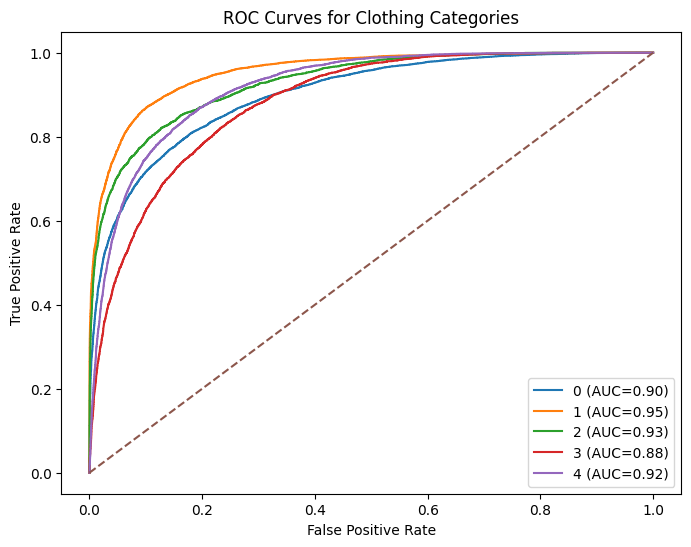


Final Scratch Results
Macro F1 : 0.736185992188401
Micro F1 : 0.7548057425581961


In [19]:
print("\n===== ResNet50 Scratch Evaluation =====")

macro_f1_scratch, micro_f1_scratch = evaluate_model(scratch_model, val_loader)

print("\nFinal Scratch Results")
print("Macro F1 :", macro_f1_scratch)
print("Micro F1 :", micro_f1_scratch)

In [20]:
torch.save(scratch_model.state_dict(), "resnet50_scratch.pth")

## Step 14: ResNet50 Model (Transfer Learning)

* Loads **ResNet50 pretrained on ImageNet**.
* Freezes all backbone layers to preserve learned features.
* Replaces the final fully connected layer for the **target clothing categories**.
* Only the **classification layer is trained** during transfer learning.


In [21]:
# ===============================
# ResNet50 Transfer Learning
# ===============================

transfer_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# Freeze entire backbone
for param in transfer_model.parameters():
    param.requires_grad = False

# Replace classifier
in_features = transfer_model.fc.in_features
transfer_model.fc = nn.Linear(in_features, NUM_CLASSES)

# Move model to GPU
transfer_model = transfer_model.to(device)

print("ResNet50 Transfer Learning ready.")

ResNet50 Transfer Learning ready.


### Loss Function and Optimizer (Transfer Learning)

* Uses **BCEWithLogitsLoss** for multi-label classification.
* Applies **positive class weights** to handle class imbalance.
* Optimizes only the **final classification layer** while the backbone remains frozen.
* Uses the **Adam optimizer with learning rate 1e-4**.


In [22]:
# ===============================
# Transfer Learning Loss & Optimizer
# ===============================

transfer_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

transfer_optimizer = torch.optim.Adam(
    transfer_model.fc.parameters(),  # only classifier trains
    lr=1e-4
)

print("Transfer learning optimizer ready.")

Transfer learning optimizer ready.


## Step 15: Transfer Learning Training Loop

* Trains the **ResNet50 transfer learning model**.
* Only the **final classifier layer is updated** while the backbone remains frozen.
* Uses **sigmoid thresholding (0.5)** for multi-label predictions.
* Computes **Macro F1-score on the validation set**.
* Saves the **best model weights based on validation Macro F1**.


In [25]:
# ===============================
# Transfer Learning Training
# ===============================

scaler = GradScaler("cuda")

best_transfer_weights = None
best_macro_f1_transfer = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    # ----- Training -----
    transfer_model.train()
    running_train_loss = 0.0

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        transfer_optimizer.zero_grad()

        with autocast(device_type="cuda"):
            outputs = transfer_model(images)
            loss = transfer_criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(transfer_optimizer)
        scaler.update()

        running_train_loss += loss.item() * images.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # ----- Validation -----
    transfer_model.eval()
    running_val_loss = 0.0

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = transfer_model(images)
            loss = transfer_criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            all_labels.append(labels.cpu().numpy())
            all_preds.append(preds.cpu().numpy())

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    all_labels = np.vstack(all_labels)
    all_preds = np.vstack(all_preds)

    macro_f1_transfer = f1_score(all_labels, all_preds, average="macro")

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss : {epoch_train_loss:.4f}")
    print(f"Val Loss   : {epoch_val_loss:.4f}")
    print(f"Macro F1   : {macro_f1_transfer:.4f}")

    if macro_f1_transfer > best_macro_f1_transfer:
        best_macro_f1_transfer = macro_f1_transfer
        best_transfer_weights = copy.deepcopy(transfer_model.state_dict())

transfer_model.load_state_dict(best_transfer_weights)

print("Best transfer learning model loaded.")

100%|██████████| 4506/4506 [11:08<00:00,  6.74it/s]



Epoch [1/8]
Train Loss : 0.7418
Val Loss   : 0.6810
Macro F1   : 0.6340


100%|██████████| 4506/4506 [11:05<00:00,  6.77it/s]



Epoch [2/8]
Train Loss : 0.7215
Val Loss   : 0.6692
Macro F1   : 0.6364


100%|██████████| 4506/4506 [11:42<00:00,  6.42it/s]


...


Epoch [6/8]
Train Loss : 0.6947
Val Loss   : 0.6491
Macro F1   : 0.6497


100%|██████████| 4506/4506 [11:28<00:00,  6.54it/s]



Epoch [7/8]
Train Loss : 0.6919
Val Loss   : 0.6490
Macro F1   : 0.6465


100%|██████████| 4506/4506 [11:30<00:00,  6.53it/s]



Epoch [8/8]
Train Loss : 0.6877
Val Loss   : 0.6562
Macro F1   : 0.6435
Best transfer learning model loaded.


### Transfer Learning Model Evaluation

* Evaluates the **ResNet50 model trained using transfer learning**.
* Computes **per-class Precision, Recall, F1-score, and ROC-AUC**.
* Reports **Macro and Micro F1 scores** for overall classification performance.



===== ResNet50 Transfer Learning Evaluation =====


100%|██████████| 742/742 [01:26<00:00,  8.57it/s]



===== Per Class Metrics =====

Class: 0
Precision: 0.8056
Recall   : 0.6788
F1-score : 0.7368
AUC      : 0.8391

Class: 1
Precision: 0.7527
Recall   : 0.7905
F1-score : 0.7711
AUC      : 0.8949

Class: 2
Precision: 0.3892
Recall   : 0.7810
F1-score : 0.5196
AUC      : 0.8454

Class: 3
Precision: 0.4306
Recall   : 0.8901
F1-score : 0.5804
AUC      : 0.8381

Class: 4
Precision: 0.5020
Recall   : 0.8844
F1-score : 0.6404
AUC      : 0.8645

===== Overall Metrics =====
Macro F1 : 0.6497
Micro F1 : 0.6641
Macro AUC: 0.8564


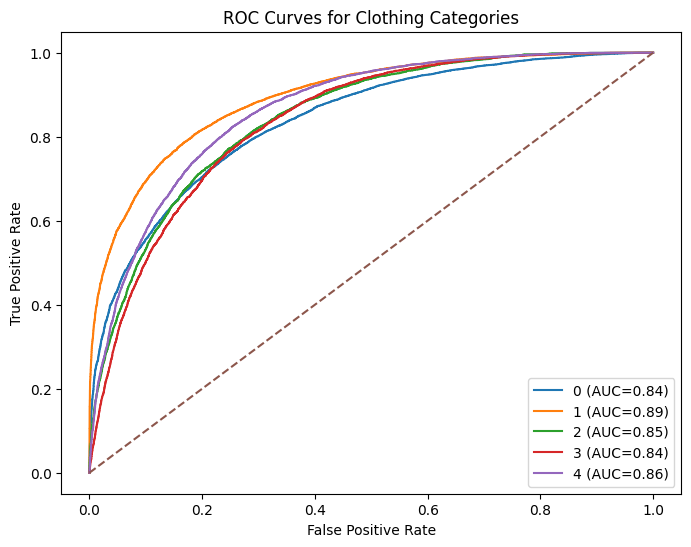


Final Transfer Learning Results
Macro F1 : 0.6496721528295106
Micro F1 : 0.6641184375757309


In [26]:
print("\n===== ResNet50 Transfer Learning Evaluation =====")

macro_f1_transfer, micro_f1_transfer = evaluate_model(transfer_model, val_loader)

print("\nFinal Transfer Learning Results")
print("Macro F1 :", macro_f1_transfer)
print("Micro F1 :", micro_f1_transfer)

In [27]:
torch.save(transfer_model.state_dict(), "resnet50_transfer_epochs.pth")

## Step 14: Compare Transfer Learning vs Scratch vs Fine Tuning

We compare:
- Macro F1
- Micro F1

In [28]:
print("\n==============================")
print("        Final Model Comparison")
print("==============================")

print(f"{'Model':<25}{'Macro F1':<12}{'Micro F1':<12}")
print("-"*45)

print(f"{'ResNet50 Transfer':<25}{macro_f1_transfer:.4f}{'':<4}{micro_f1_transfer:.4f}")
print(f"{'ResNet50 Fine-Tune':<25}{macro_f1:.4f}{'':<4}{micro_f1:.4f}")
print(f"{'ResNet50 Scratch':<25}{macro_f1_scratch:.4f}{'':<4}{micro_f1_scratch:.4f}")


        Final Model Comparison
Model                    Macro F1    Micro F1    
---------------------------------------------
ResNet50 Transfer        0.6497    0.6641
ResNet50 Fine-Tune       0.7362    0.8632
ResNet50 Scratch         0.7362    0.7548
